# Pelatihan Model Embedding Telapak Tangan (v5)

Improvement dari v4 untuk **dataset terbatas (28 orang)**:
- Evaluasi **cross-validation**: per fold 18 train / 3 enrolled / 3 unknown / 4 val, diulang K kali, skor di-pool menjadi satu **EER +/- 95% CI**.
- Training: **progressive unfreezing** + **BatchNorm freeze** + **cosine LR** + **label smoothing**.
- Enroll & probe pakai **TTA** (rata-rata embedding atas rotasi kecil).
- Augmentasi mengikuti v2; alur sel rapi seperti v1.

## 1. Setup, Dependencies & Konfigurasi

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q tensorflow numpy mediapipe scikit-learn matplotlib tqdm
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.9 MB/s eta 0:00:00


In [3]:
import os, json, math, random, glob
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import roc_curve, auc

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --- Path ---
RAW_DIR      = '/content/drive/MyDrive/Skripsi/dataset_mentah'
ROI_DIR      = '/content/drive/MyDrive/Skripsi/dataset_roi'
LANDMARKER   = 'hand_landmarker.task'
ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# --- Preprocessing (HARUS identik dengan device) ---
IMG_SIZE       = (224, 224)
CLAHE_CLIP     = 2.0
CLAHE_TILE     = (8, 8)
PALM_ROI_SCALE = 1.5
MIN_PALM_WIDTH = 40.0
MIN_SHARPNESS  = 25.0

# --- Model ---
EMBED_DIM    = 128
BATCH        = 32
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
N_GALLERY    = 4

# --- Two-stage training ---
STAGE1_EPOCHS  = 25
STAGE2_EPOCHS  = 80
LR_STAGE1      = 1e-3
LR_STAGE2      = 1e-4
UNFREEZE_LAST  = 20      # progressive unfreeze: hanya N layer terakhir di stage-2
FREEZE_BN      = True    # bekukan BatchNorm saat fine-tune
ES_PATIENCE_S1 = 10
ES_PATIENCE_S2 = 15

# --- ArcFace ---
ARC_S = 30.0
ARC_M_FINAL = 0.30
ARC_M_WARMUP_EPOCHS = 8

# --- Cross-Validation (18 train / 3 enrolled / 3 unknown / 4 val) ---
N_TEST_ENROLLED = 3
N_TEST_UNKNOWN  = 3
N_VAL_IDS       = 4
N_FOLDS         = 10
SPLIT_BY_HAND_TRAIN = False   # True -> kiri/kanan = kelas beda saat TRAIN (eval tetap per-orang)

# --- TTA, threshold, bootstrap ---
TTA_ROTATIONS = [0.0, -6.0, 6.0]
TARGET_FAR    = [0.001, 0.01]
BOOTSTRAP_B   = 2000

print('TF:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Ekstraksi ROI (MediaPipe) + Quality Gate

In [4]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

_base = mp_python.BaseOptions(model_asset_path=LANDMARKER)
_opts = vision.HandLandmarkerOptions(base_options=_base, num_hands=1,
                                     running_mode=vision.RunningMode.IMAGE)
_landmarker = vision.HandLandmarker.create_from_options(_opts)
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def roi_sharpness(roi_rgb):
    g = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())

def extract_palm_roi(bgr):
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = _landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
    if not res.hand_landmarks:
        return None
    lm = res.hand_landmarks[0]
    def p(i):
        return np.array([lm[i].x * w, lm[i].y * h], dtype=np.float32)
    wrist, idx_mcp, mid_mcp, pinky_mcp = p(0), p(5), p(9), p(17)
    palm_w = float(np.linalg.norm(idx_mcp - pinky_mcp))
    if palm_w < MIN_PALM_WIDTH:
        return None
    angle = math.degrees(math.atan2(pinky_mcp[1]-idx_mcp[1], pinky_mcp[0]-idx_mcp[0]))
    center = (wrist + mid_mcp) / 2.0
    R = cv2.getRotationMatrix2D((float(center[0]), float(center[1])), angle, 1.0)
    rot = cv2.warpAffine(bgr, R, (w, h))
    half = (palm_w * PALM_ROI_SCALE) / 2.0
    cx, cy = float(center[0]), float(center[1])
    x1, y1 = int(max(0, cx-half)), int(max(0, cy-half))
    x2, y2 = int(min(w, cx+half)), int(min(h, cy+half))
    crop = rot[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    gray = _clahe.apply(cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY))
    roi = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return cv2.resize(roi, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

## 3. Bangun Dataset ROI (sekali jalan)

In [10]:
SKIP_IF_EXISTS = True

def hand_of(filename):
    parts = os.path.splitext(filename)[0].split('_')
    if len(parts) >= 3 and parts[2].upper() in ('L', 'R'):
        return parts[2].upper()
    f = filename.lower()
    if any(k in f for k in ['left', 'kiri']):  return 'L'
    if any(k in f for k in ['right', 'kanan']): return 'R'
    return 'X'

def _retry_detect(img):
    roi = extract_palm_roi(img)
    if roi is not None:
        return roi
    for op in [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE, cv2.ROTATE_180]:
        roi = extract_palm_roi(cv2.rotate(img, op))
        if roi is not None:
            return roi
    return extract_palm_roi(cv2.flip(img, 1))

In [5]:
def build_roi_dataset():
    if SKIP_IF_EXISTS and os.path.isdir(ROI_DIR) and any(
            os.path.isdir(os.path.join(ROI_DIR, d)) for d in os.listdir(ROI_DIR)):
        print('ROI_DIR sudah berisi data; lewati ekstraksi.')
        return
    persons = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
    ok = miss = blur = bad = 0
    for person in tqdm(persons, desc='ROI'):
        pdir = os.path.join(RAW_DIR, person)
        for fn in sorted(os.listdir(pdir)):
            if not fn.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                continue
            img = cv2.imread(os.path.join(pdir, fn))
            if img is None:
                bad += 1; continue
            roi = _retry_detect(img)
            if roi is None:
                miss += 1; continue
            if roi_sharpness(roi) < MIN_SHARPNESS:
                blur += 1; continue
            outdir = os.path.join(ROI_DIR, person)
            os.makedirs(outdir, exist_ok=True)
            cv2.imwrite(os.path.join(outdir, os.path.splitext(fn)[0] + '.png'),
                        cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))
            ok += 1
    print('Selesai. ok=', ok, '| gagal_baca=', bad, '| gagal_deteksi=', miss, '| ditolak_blur=', blur)

build_roi_dataset()

ROI: 100%|██████████| 28/28 [37:20<00:00, 80.01s/it]

Selesai. ok= 1009 | gagal_baca= 0 | gagal_deteksi= 111 | ditolak_blur= 0


## 4. Indeks Identitas & Helper Embedding (+ TTA)

In [5]:
ALL_IDS = sorted([d for d in os.listdir(ROI_DIR) if os.path.isdir(os.path.join(ROI_DIR, d))])
print('Total identitas:', len(ALL_IDS))

def imgs_of(label):
    return sorted(glob.glob(os.path.join(ROI_DIR, label, '*.png')))

def load_img(path):
    return cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), IMG_SIZE).astype(np.float32)

def _rotate(img, deg):
    if deg == 0:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2.0, h/2.0), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def embed_paths(model, paths, tta=None, batch=64):
    if tta is None:
        tta = TTA_ROTATIONS
    if len(paths) == 0:
        return np.zeros((0, EMBED_DIM), np.float32)
    base = [load_img(p) for p in paths]
    accum = np.zeros((len(paths), EMBED_DIM), np.float32)
    for deg in tta:
        e = model.predict(np.stack([_rotate(im, deg) for im in base]), verbose=0, batch_size=batch)
        accum += e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
    accum /= len(tta)
    return (accum / (np.linalg.norm(accum, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

Total identitas: 28


## 5. Model, Augmentasi (v2) & ArcFace

In [6]:
def make_augment():
    return tf.keras.Sequential([
        layers.RandomTranslation(0.06, 0.06, fill_mode='constant', fill_value=0.0),
        layers.RandomRotation(0.03, fill_mode='constant', fill_value=0.0),
        layers.RandomZoom(0.10, fill_mode='constant', fill_value=0.0),
        layers.RandomContrast(0.15),
    ], name='augment')

class ArcMarginProduct(layers.Layer):
    def __init__(self, n_classes, s=30.0, m=0.50, **kwargs):
        super().__init__(**kwargs)
        self.n_classes = n_classes; self.s = s; self._m_init = m
    def build(self, input_shape):
        self.W = self.add_weight(name='arc_W', shape=(int(input_shape[0][-1]), self.n_classes),
                                 initializer='glorot_uniform', trainable=True)
        self.m = tf.Variable(self._m_init, trainable=False, dtype=tf.float32, name='arc_m')
    def call(self, inputs):
        emb, labels = inputs
        W = tf.nn.l2_normalize(self.W, axis=0)
        cos_t = tf.clip_by_value(tf.matmul(emb, W), -1.0 + 1e-7, 1.0 - 1e-7)
        target = tf.cos(tf.acos(cos_t) + self.m)
        logits = cos_t * (1.0 - labels) + target * labels
        return tf.nn.softmax(logits * self.s)
    def get_config(self):
        c = super().get_config(); c.update(n_classes=self.n_classes, s=self.s, m=self._m_init); return c

def build_embedding_model(embed_dim=EMBED_DIM):
    backbone = EfficientNetB0(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
    inp = Input(IMG_SIZE + (3,))
    x = backbone(inp)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(embed_dim, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1), name='embedding')(x)
    return models.Model(inp, x, name='embedding_model'), backbone

def build_train_model(num_classes):
    em, bb = build_embedding_model()
    img_in = Input(IMG_SIZE + (3,), name='image')
    lbl_in = Input((num_classes,), name='label')
    emb = em(make_augment()(img_in))
    out = ArcMarginProduct(num_classes, s=ARC_S, m=ARC_M_FINAL, name='arcface')([emb, lbl_in])
    return models.Model([img_in, lbl_in], out, name='trainer'), em, bb

def set_finetune(backbone, unfreeze_last=UNFREEZE_LAST, freeze_bn=FREEZE_BN):
    backbone.trainable = True
    n = len(backbone.layers)
    for i, l in enumerate(backbone.layers):
        t = i >= (n - unfreeze_last)
        if freeze_bn and isinstance(l, layers.BatchNormalization):
            t = False
        l.trainable = t

## 6. Rutin Latihan per Fold (dua tahap)

In [7]:
def _ds_from(paths, labels, num_classes):
    def _load(p, y):
        img = tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(p), channels=3), IMG_SIZE), tf.float32)
        return img, tf.one_hot(y, num_classes)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).shuffle(len(paths), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE).map(lambda im, oh: ((im, oh), oh), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

def build_train_index(train_ids, split_by_hand):
    classes, pbc = [], {}
    for pid in train_ids:
        files = imgs_of(pid)
        if split_by_hand:
            g = {}
            for f in files:
                g.setdefault(hand_of(os.path.basename(f)), []).append(f)
            for h, fs in g.items():
                c = pid + '__' + h; classes.append(c); pbc[c] = fs
        else:
            classes.append(pid); pbc[pid] = files
    return classes, pbc

class EERValidation(tf.keras.callbacks.Callback):
    def __init__(self, em, val_ids, n_gallery=N_GALLERY):
        super().__init__(); self.em = em
        self.files = {p: imgs_of(p) for p in val_ids}; self.n_gallery = n_gallery
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        tem, prb = {}, []
        for p, fs in self.files.items():
            fs2 = list(fs); random.Random(SEED).shuffle(fs2)
            g, q = fs2[:self.n_gallery], fs2[self.n_gallery:]
            if not g or not q:
                continue
            t = embed_paths(self.em, g, tta=[0.0]).mean(0); tem[p] = t / (np.linalg.norm(t) + 1e-9)
            for v in embed_paths(self.em, q, tta=[0.0]):
                prb.append((v, p))
        if len(tem) < 2 or not prb:
            logs['val_eer'] = 1.0; return
        ids = list(tem); M = np.stack([tem[i] for i in ids]); gen, imp = [], []
        for v, tp in prb:
            sims = M @ v
            for i, idp in enumerate(ids):
                (gen if idp == tp else imp).append(float(sims[i]))
        fpr, tpr, _ = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
        fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
        logs['val_eer'] = float((fpr[i] + fnr[i]) / 2.0)

class MarginWarmup(tf.keras.callbacks.Callback):
    def __init__(self, layer, m_final, warmup):
        super().__init__(); self.layer = layer; self.m_final = m_final; self.warm = max(1, warmup); self.g = 0
    def on_epoch_begin(self, epoch, logs=None):
        self.layer.m.assign(self.m_final * min(1.0, (self.g + 1) / self.warm)); self.g += 1

def make_opt(lr):
    try:
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY)
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=lr)

def fit_model(train_ids, val_ids=None, split_by_hand=SPLIT_BY_HAND_TRAIN):
    tf.keras.backend.clear_session()
    classes, pbc = build_train_index(train_ids, split_by_hand)
    nc = len(classes); idx = {c: i for i, c in enumerate(classes)}
    paths, labels = [], []
    for c in classes:
        for f in pbc[c]:
            paths.append(f); labels.append(idx[c])
    ds = _ds_from(paths, labels, nc); steps = max(1, math.ceil(len(paths) / BATCH))
    tm, em, bb = build_train_model(nc); arc = tm.get_layer('arcface')
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
    eer_cb = [EERValidation(em, val_ids)] if val_ids else []
    # Tahap 1: head warmup (backbone beku)
    bb.trainable = False
    tm.compile(make_opt(LR_STAGE1), loss=loss, metrics=['accuracy'])
    cb1 = [MarginWarmup(arc, ARC_M_FINAL, ARC_M_WARMUP_EPOCHS)] + eer_cb
    if val_ids:
        cb1.append(tf.keras.callbacks.EarlyStopping('val_eer', mode='min', patience=ES_PATIENCE_S1, restore_best_weights=True))
    tm.fit(ds, epochs=STAGE1_EPOCHS, callbacks=cb1, verbose=0)
    # Tahap 2: progressive unfreeze + BN freeze + cosine LR
    set_finetune(bb); arc.m.assign(ARC_M_FINAL)
    sched = tf.keras.optimizers.schedules.CosineDecay(LR_STAGE2, STAGE2_EPOCHS * steps)
    tm.compile(tf.keras.optimizers.AdamW(learning_rate=sched, weight_decay=WEIGHT_DECAY), loss=loss, metrics=['accuracy'])
    cb2 = list(eer_cb)
    if val_ids:
        cb2.append(tf.keras.callbacks.EarlyStopping('val_eer', mode='min', patience=ES_PATIENCE_S2, restore_best_weights=True))
    tm.fit(ds, epochs=STAGE2_EPOCHS, callbacks=cb2, verbose=0)
    return em

## 7. Evaluasi per Fold (enroll + probe + unknown)

In [8]:
def evaluate_fold(em, enrolled_ids, unknown_ids):
    templates, probes = {}, []
    for pid in enrolled_ids:
        by_hand = {}
        for f in imgs_of(pid):
            by_hand.setdefault(hand_of(os.path.basename(f)), []).append(f)
        temps, pf = [], []
        for h, fs in by_hand.items():
            fs = list(fs); random.Random(SEED).shuffle(fs)
            g, q = fs[:N_GALLERY], fs[N_GALLERY:]
            if g:
                t = embed_paths(em, g).mean(0); temps.append(t / (np.linalg.norm(t) + 1e-9))
            pf += q
        if temps:
            templates[pid] = np.stack(temps)
        for v in embed_paths(em, pf):
            probes.append((v, pid))
    persons = list(templates)
    def ps(v, pid):
        return float(np.max(templates[pid] @ v))
    gen, imp, probe_best = [], [], []
    for v, tp in probes:
        sc = {pid: ps(v, pid) for pid in persons}
        for pid in persons:
            (gen if pid == tp else imp).append(sc[pid])
        bp = max(sc, key=sc.get); probe_best.append((sc[bp], bp == tp))
    unk_imp, unk_max = [], []
    for pid in unknown_ids:
        for v in embed_paths(em, imgs_of(pid)):
            s = [ps(v, q) for q in persons]; unk_imp += s; unk_max.append(max(s))
    return dict(gen=gen, imp=imp + unk_imp, probe_best=probe_best, unk_max=unk_max)

## 8. Cross-Validation Loop (pooled EER +/- 95% CI)

Fold 1 / 10 | train= 18 | EER=0.00%
Fold 2 / 10 | train= 18 | EER=4.83%
Fold 3 / 10 | train= 18 | EER=1.04%
Fold 4 / 10 | train= 18 | EER=0.52%
Fold 5 / 10 | train= 18 | EER=2.58%
Fold 6 / 10 | train= 18 | EER=11.49%
Fold 7 / 10 | train= 18 | EER=7.32%
Fold 8 / 10 | train= 18 | EER=1.91%
Fold 9 / 10 | train= 18 | EER=1.14%
Fold 10 / 10 | train= 18 | EER=1.17%

==== HASIL CROSS-VALIDATION ====
Fold=10 | identitas teruji=26/28
EER per-fold: mean=3.20% +/-2.27% (95%CI) | min=0.00% max=11.49%
EER pooled  : 4.48% | bootstrap 95%CI=[3.68%, 5.50%] | AUC=0.9872

Threshold pada target FAR (skor pooled):
  FAR<=0.1% -> thr=0.8074 | Rank-1=88.26% | FRR=11.74% | OpenFA=0.28%
  FAR<=1.0% -> thr=0.7459 | Rank-1=92.28% | FRR=7.72% | OpenFA=4.61%


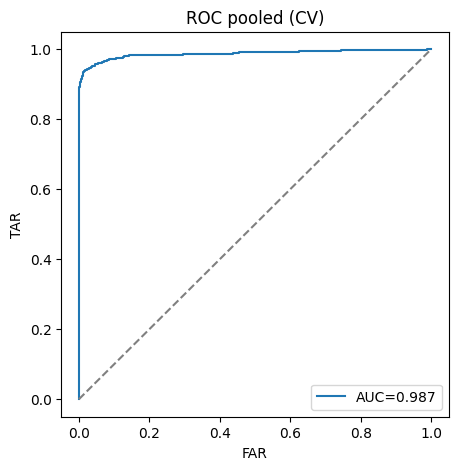

In [11]:
def make_folds(all_ids, k, n_enr, n_unk, n_val, seed=SEED):
    fl = []
    for f in range(k):
        ids = list(all_ids); random.Random(seed + f).shuffle(ids)
        a, b, c = n_enr, n_enr + n_unk, n_enr + n_unk + n_val
        fl.append(dict(enrolled=ids[:a], unknown=ids[a:b], val=ids[b:c], train=ids[c:]))
    return fl

def compute_eer(gen, imp):
    fpr, tpr, thr = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
    fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
    return float(auc(fpr, tpr)), float((fpr[i] + fnr[i]) / 2.0), fpr, tpr, thr

def bootstrap_eer(gen, imp, B=BOOTSTRAP_B, seed=SEED):
    rng = np.random.default_rng(seed); gen = np.asarray(gen); imp = np.asarray(imp); out = []
    for _ in range(B):
        _, e, _, _, _ = compute_eer(rng.choice(gen, len(gen), True), rng.choice(imp, len(imp), True))
        out.append(e)
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

folds = make_folds(ALL_IDS, N_FOLDS, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS)
G, I, per_fold_eer, all_pb, all_unk, tested = [], [], [], [], [], set()
for k, fd in enumerate(folds):
    em = fit_model(fd['train'], fd['val'])
    r = evaluate_fold(em, fd['enrolled'], fd['unknown'])
    g, im = np.array(r['gen']), np.array(r['imp'])
    _, eer, _, _, _ = compute_eer(g, im); per_fold_eer.append(eer)
    G.append(g); I.append(im); all_pb += r['probe_best']; all_unk += r['unk_max']
    tested |= set(fd['enrolled']) | set(fd['unknown'])
    print('Fold', k + 1, '/', N_FOLDS, '| train=', len(fd['train']), '| EER=%.2f%%' % (eer * 100))

G, I = np.concatenate(G), np.concatenate(I)
AUC, EER, fpr, tpr, thr = compute_eer(G, I); lo, hi = bootstrap_eer(G, I); pf = np.array(per_fold_eer)
print('\n==== HASIL CROSS-VALIDATION ====')
print('Fold=%d | identitas teruji=%d/%d' % (N_FOLDS, len(tested), len(ALL_IDS)))
print('EER per-fold: mean=%.2f%% +/-%.2f%% (95%%CI) | min=%.2f%% max=%.2f%%' % (
    pf.mean() * 100, 1.96 * pf.std(ddof=1) / np.sqrt(len(pf)) * 100, pf.min() * 100, pf.max() * 100))
print('EER pooled  : %.2f%% | bootstrap 95%%CI=[%.2f%%, %.2f%%] | AUC=%.4f' % (EER * 100, lo * 100, hi * 100, AUC))

def thr_at_far(ft):
    ok = np.where(fpr <= ft)[0]; return float(thr[ok[-1] if len(ok) else 0])

print('\nThreshold pada target FAR (skor pooled):')
for ft in TARGET_FAR:
    T = thr_at_far(ft)
    rank1 = np.mean([(s >= T and ok) for s, ok in all_pb])
    frr = np.mean([s < T for s, _ in all_pb])
    openfa = np.mean([s >= T for s in all_unk]) if all_unk else 0.0
    print('  FAR<=%.1f%% -> thr=%.4f | Rank-1=%.2f%% | FRR=%.2f%% | OpenFA=%.2f%%' % (
        ft * 100, T, rank1 * 100, frr * 100, openfa * 100))

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='AUC=%.3f' % AUC); plt.plot([0, 1], [0, 1], '--', c='gray')
plt.xlabel('FAR'); plt.ylabel('TAR'); plt.title('ROC pooled (CV)'); plt.legend(); plt.show()

## 9. Latih Model Final (semua identitas) & Ekspor

In [12]:
# CV sudah memberi estimasi jujur; model final dilatih pada SEMUA identitas.
embedding_model = fit_model(ALL_IDS, val_ids=ALL_IDS[:N_VAL_IDS])
OPERATING_FAR = max(TARGET_FAR)
OPERATING_THRESHOLD = thr_at_far(OPERATING_FAR)
print('OPERATING_THRESHOLD =', round(OPERATING_THRESHOLD, 4))

embedding_model.save(os.path.join(ARTIFACT_DIR, 'palm_embedding.keras'))
conv = tf.lite.TFLiteConverter.from_keras_model(embedding_model)
# float32 = akurasi terbaik (fp16 menaikkan EER pada v4). Untuk fp16, buka 2 baris ini:
# conv.optimizations = [tf.lite.Optimize.DEFAULT]
# conv.target_spec.supported_types = [tf.float16]
open(os.path.join(ARTIFACT_DIR, 'palm_embedding.tflite'), 'wb').write(conv.convert())

meta = {'embedding_dim': EMBED_DIM, 'img_size': list(IMG_SIZE), 'input_range': '0-255 float32',
        'similarity': 'cosine L2-norm', 'operating_threshold': OPERATING_THRESHOLD,
        'operating_far': OPERATING_FAR, 'cv_eer_pooled': EER, 'cv_eer_ci95': [lo, hi],
        'cv_auc': AUC, 'tta_rotations': TTA_ROTATIONS, 'split_by_hand_train': SPLIT_BY_HAND_TRAIN,
        'preprocessing': 'MediaPipe ROI -> gray -> CLAHE(2.0,8x8) -> GRAY2RGB -> resize 224'}
json.dump(meta, open(os.path.join(ARTIFACT_DIR, 'model_metadata.json'), 'w'), indent=2)
print(json.dumps(meta, indent=2))

OPERATING_THRESHOLD = 0.7459
Saved artifact at '/tmp/tmpxm9ggh1s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 128), dtype=tf.float32, name=None)
Captures:
  138332324599120: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138332324599888: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138332075108752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075105680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075109136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075106832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075110096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075100688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138332075110864: TensorSpec(sha

## 10. Integrasi ke Device

- Ganti `palm_recognition.tflite` -> `palm_embedding.tflite`; model kini mengeluarkan **embedding** langsung (hapus trik `experimental_preserve_all_tensors`).
- Input **0-255 float32** (jangan dibagi 255). Preprocessing harus identik dengan sel 2.
- Enrollment = rata-rata embedding L2 per tangan; matching = **MAX cosine** terhadap semua template.
- Set `SIMILARITY_THRESHOLD = OPERATING_THRESHOLD` di config device.
- Catatan: gunakan **float32** dulu untuk skripsi; kuantisasi int8 (dgn representative dataset) hanya jika perlu ukuran kecil.